# Libraries and functions

In [1]:
import numpy as np

import sys
from pathlib import Path
import os

# path to the directory that CONTAINS the package folder
project_root = Path("/mnt/beegfs/2a/mb12724/franc/theory-language-modeling/")   # adjust to your real path

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from BP.constrained_bp_last_next_torch import simulate_constrained_bp_sweep

In [2]:
from BP.plot_constrained_bp_results import (
    load_results,
    plot_loss_error,
    plot_budget_diagnostics,
    plot_hierarchy_observables,
    plot_loss_decomposition,
    plot_validity_by_position,
    plot_peeled_loss_and_margin_fraction,
)


# Flat rules

In [3]:
name_save = "v2_bp_global_L4_s2_v32_m4_v2"

In [4]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_constrained_bp_sweep(
    num_features=32,
    num_classes=32,
    num_synonyms=4,
    tuple_size=2,
    num_layers=4,
    train_size=1024,
    test_size=4096,
    lambda_values=np.logspace(-2,6,200),
    seed_rules=1,
    seed_sample=1,
    prediction_mode="last",
    budget_scope="per_inference",
    device="cpu",
    batch_size=1024,
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

last BP sweep (per_inference):   2%|▎         | 5/200 [01:35<1:02:04, 19.10s/it]


KeyboardInterrupt: 

In [ ]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

## L=3

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='target message budget $\\lambda$', ylabel='mean test cross-entropy'>,
        <Axes: title={'center': 'Error'}, xlabel='target message budget $\\lambda$', ylabel='mean top-1 error'>],
       dtype=object))

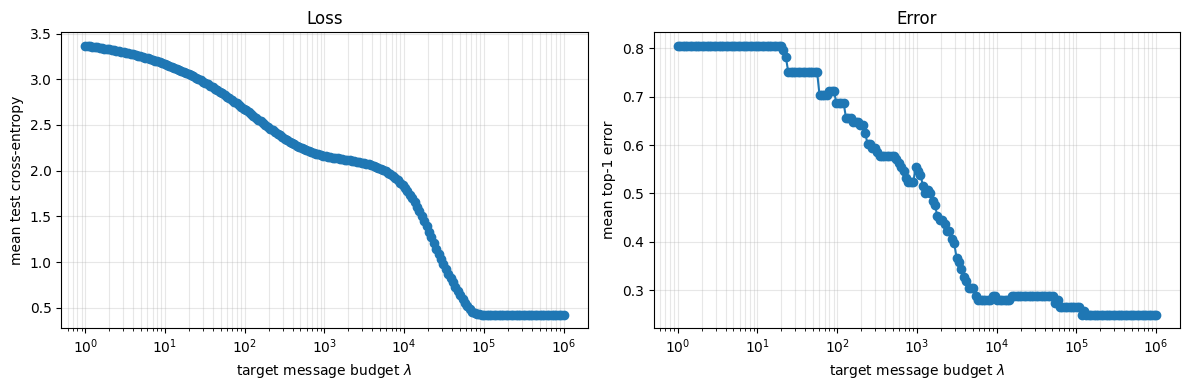

In [ ]:
plot_loss_error(res, x_key="lambda_values")

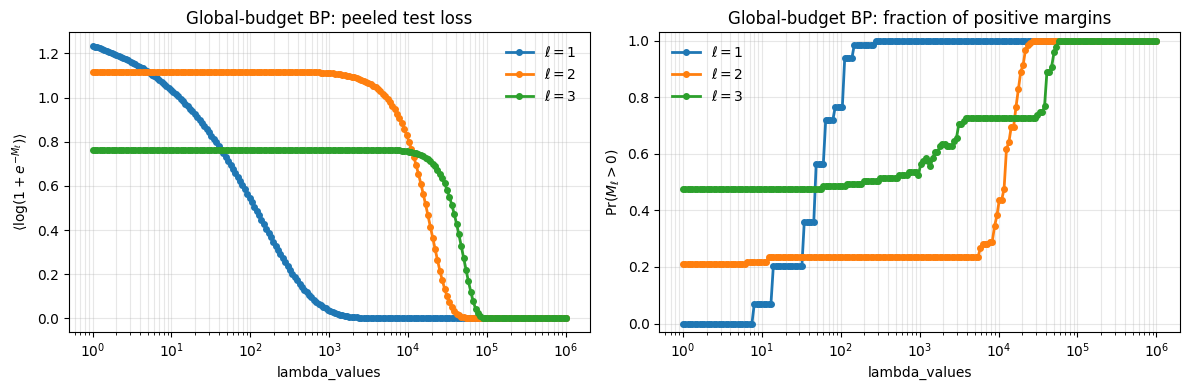

In [16]:
fig, axs = plot_peeled_loss_and_margin_fraction(
    res,
    x_key="lambda_values"
)

## L=4

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='target message budget $\\lambda$', ylabel='mean test cross-entropy'>,
        <Axes: title={'center': 'Error'}, xlabel='target message budget $\\lambda$', ylabel='mean top-1 error'>],
       dtype=object))

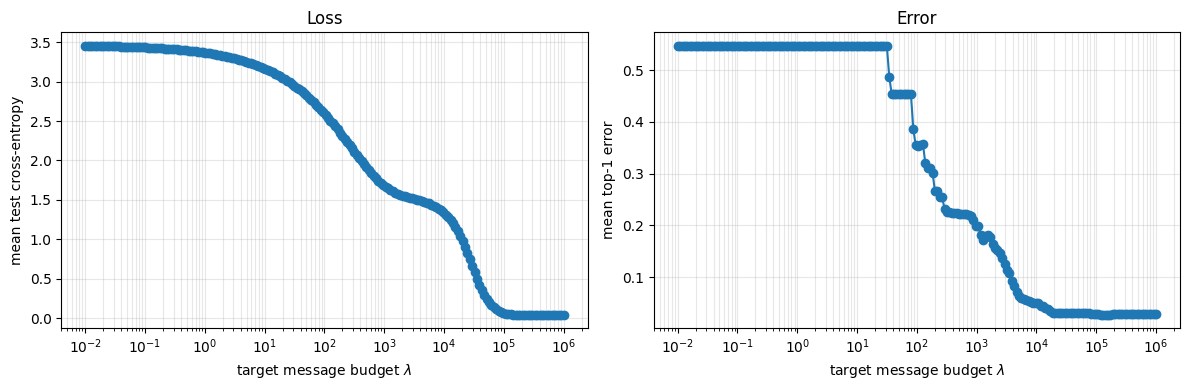

In [29]:
plot_loss_error(res, x_key="lambda_values")

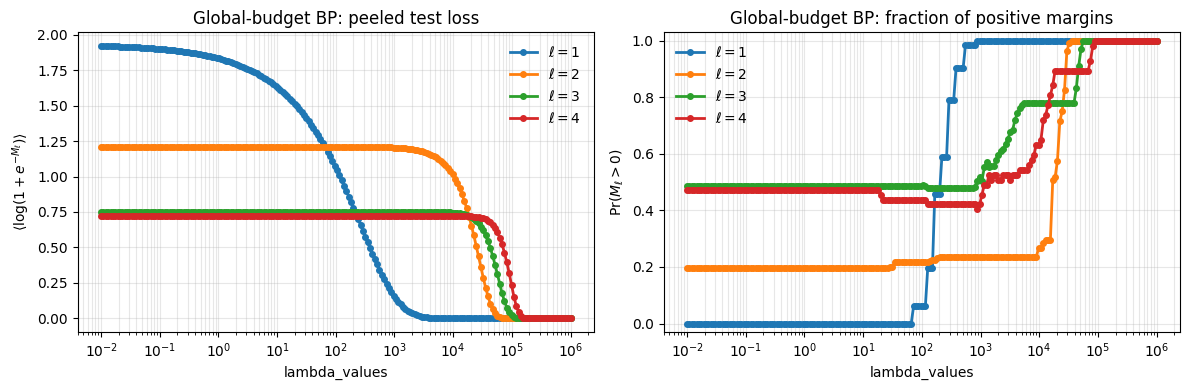

In [30]:
fig, axs = plot_peeled_loss_and_margin_fraction(
    res,
    x_key="lambda_values"
)

# A=2

In [2]:
name_save = "A2_bp_global_budget_L3_s2_v32_m8"

In [3]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_bp_lambda_sweep(
    num_features=32,
    num_classes=32,
    num_synonyms=8,
    tuple_size=2,
    num_layers=3,
    train_size=32768,
    test_size=128,
    lambda_values=np.logspace(1., 7.0, 20),
    seed_rules=1,
    seed_sample=1,
    zipf=2,   # exponent is 1+zipf
    layer=1,    # exact repo convention: layer index starts at 1
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

100%|██████████| 20/20 [25:48<00:00, 77.42s/it] 


In [4]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

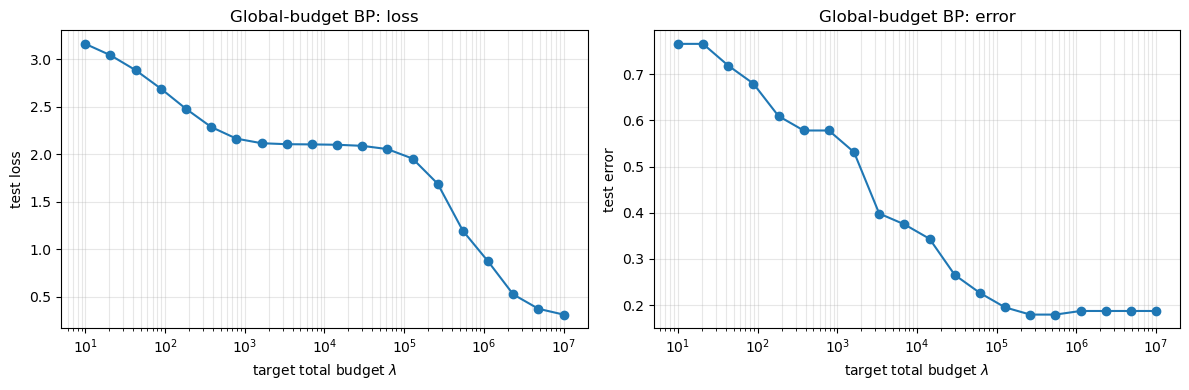

In [5]:
fig, axs = plot_both(res)

In [ ]:
fig2, axs2 = plot_hierarchy_observables(res)